In [39]:
import numpy as np

In [40]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

print(rain.shape)

(6373890,)


In [41]:
rain = rain.reshape(366,129,135)

print(rain.shape)

(366, 129, 135)


In [42]:
print(rain.min())
print(rain.max())

-999.0
660.5492


In [43]:
rain = np.where(
    rain == -999,
    np.nan,
    rain
)

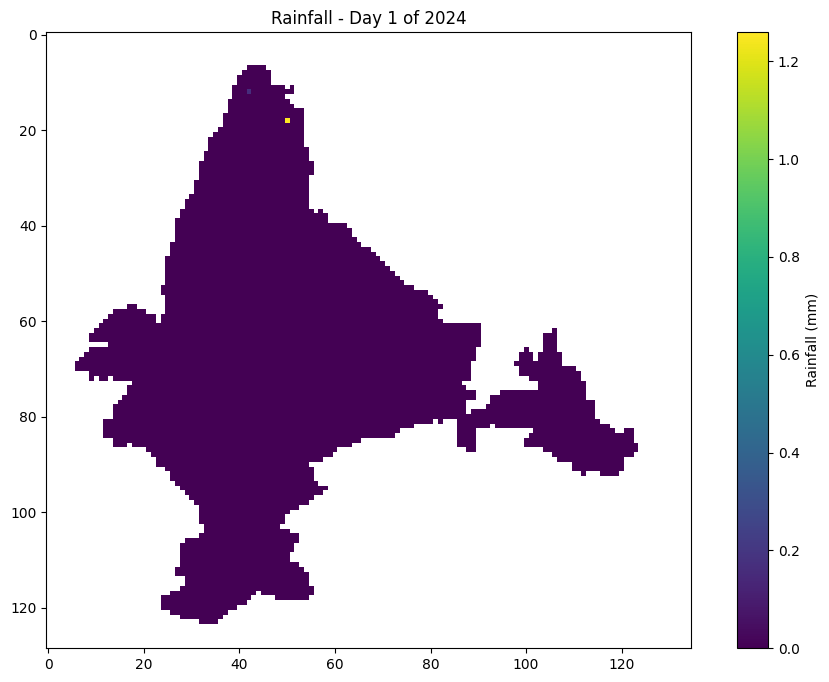

In [44]:
import matplotlib.pyplot as plt

day0 = rain[0]

plt.figure(figsize=(12,8))
plt.imshow(day0)
plt.colorbar(label="Rainfall (mm)")
plt.title("Rainfall - Day 1 of 2024")
plt.show()

In [45]:
print("Mean:", np.nanmean(rain))
print("Median:", np.nanmedian(rain))
print("Max:", np.nanmax(rain))

Mean: 3.3205583
Median: 0.0
Max: 660.5492


In [46]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

print(rain.shape)

(6373890,)


In [47]:
rain = np.where(
    rain == -999,
    np.nan,
    rain
)

In [48]:
latitudes = np.linspace(
    38.5,
    6.5,
    129
)

longitudes = np.linspace(
    66.5,
    100.0,
    135
)

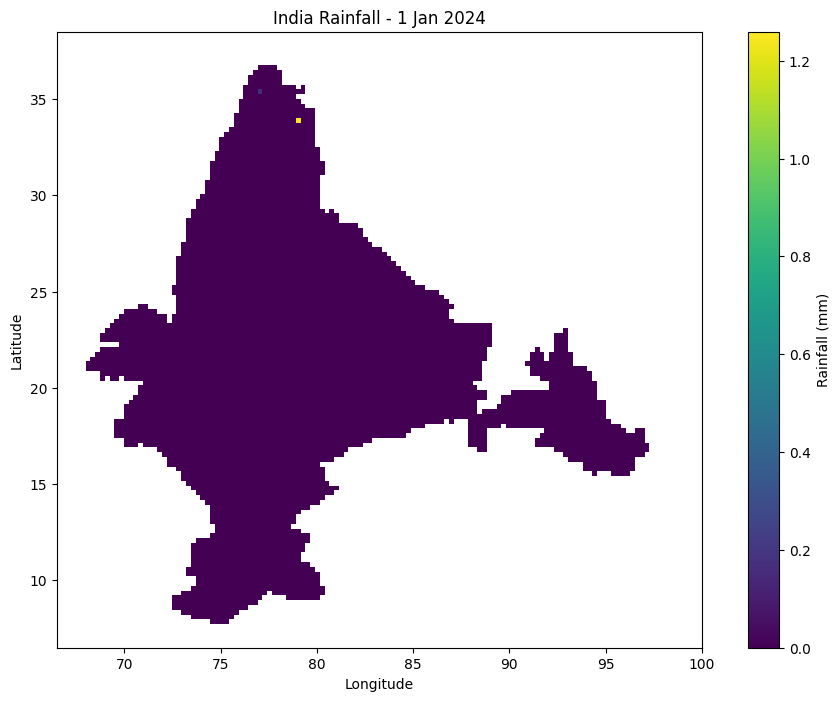

In [49]:
plt.figure(figsize=(12,8))

plt.imshow(
    day0,
    extent=[
        longitudes.min(),
        longitudes.max(),
        latitudes.min(),
        latitudes.max()
    ]
)

plt.colorbar(label="Rainfall (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("India Rainfall - 1 Jan 2024")

plt.show()

In [50]:
print(np.nanmin(day0))
print(np.nanmax(day0))
print(np.nanmean(day0))

0.0
1.2592779
0.00028648382


In [51]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

wettest_day = np.argmax(daily_mean)

print("Wettest Day Index:", wettest_day)
print("Mean Rainfall:", daily_mean[wettest_day])

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
print(rain.shape)

(6373890,)


In [ ]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

rain = rain.reshape(366,129,135)

rain = np.where(
    rain == -999,
    np.nan,
    rain
)

print(rain.shape)

(366, 129, 135)


In [ ]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

In [ ]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

wettest_day = np.argmax(daily_mean)

print("Wettest Day Index:", wettest_day)
print("Mean Rainfall:", daily_mean[wettest_day])

Wettest Day Index: 215
Mean Rainfall: 15.829672


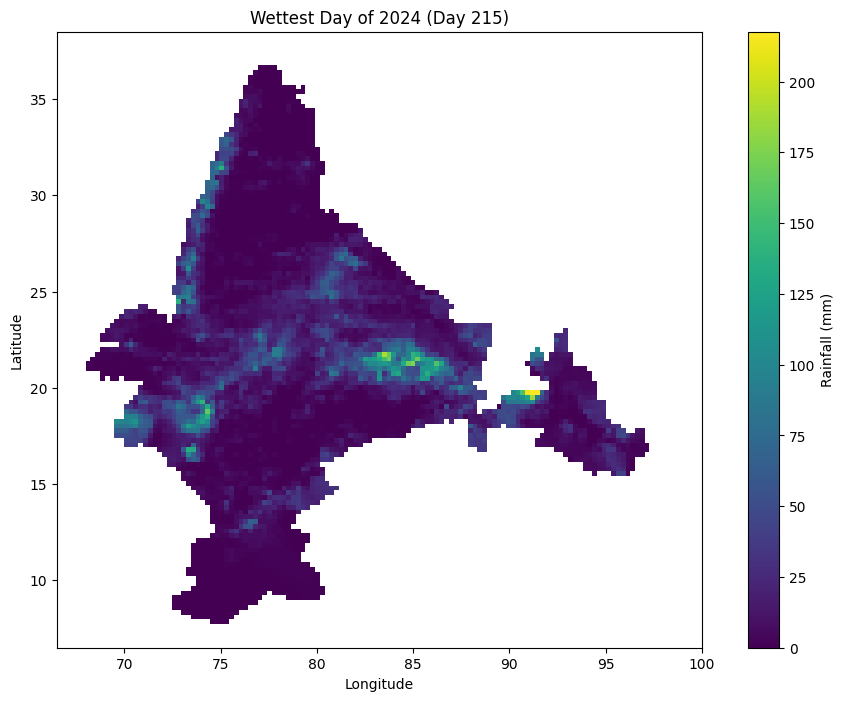

In [ ]:
wettest = rain[wettest_day]

plt.figure(figsize=(12,8))

plt.imshow(
    wettest,
    extent=[
        longitudes.min(),
        longitudes.max(),
        latitudes.min(),
        latitudes.max()
    ]
)

plt.colorbar(label="Rainfall (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Wettest Day of 2024 (Day {wettest_day})")

plt.show()

In [ ]:
#Temp data

In [ ]:
temp = np.fromfile(
    "../data/raw/Maxtemp_MaxT_2024.GRD",
    dtype=np.float32
)

print(temp.shape)

(351726,)


In [ ]:
temp = temp.reshape(366,31,31)

print(temp.shape)

(366, 31, 31)


In [ ]:
print(temp.min())
print(temp.max())

3.5872378
99.9


In [ ]:
temp = np.where(
    temp == 99.9,
    np.nan,
    temp
)

In [ ]:
print("Min:", np.nanmin(temp))
print("Max:", np.nanmax(temp))
print("Mean:", np.nanmean(temp))

Min: 3.5872378
Max: 48.09463
Mean: 30.920702


In [ ]:
print(temp.shape)

(366, 31, 31)


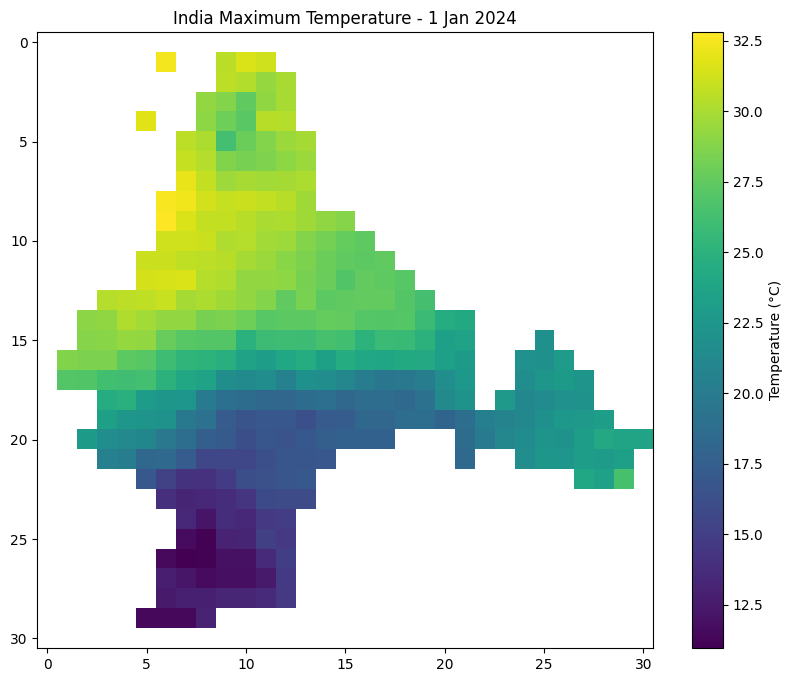

In [ ]:
day0_temp = temp[0]

plt.figure(figsize=(10,8))

plt.imshow(day0_temp)

plt.colorbar(label="Temperature (°C)")
plt.title("India Maximum Temperature - 1 Jan 2024")

plt.show()

In [ ]:
from dataclasses import dataclass


@dataclass
class ClimateState:
    date: str
    latitude: float
    longitude: float
    rainfall_mm: float
    max_temperature_c: float

In [ ]:
state = ClimateState(
    date="2024-01-01",
    latitude=19.07,
    longitude=72.88,
    rainfall_mm=0.0,
    max_temperature_c=31.2
)

print(state)

ClimateState(date='2024-01-01', latitude=19.07, longitude=72.88, rainfall_mm=0.0, max_temperature_c=31.2)


In [ ]:
import sys
sys.path.append("..")

In [ ]:
from src.ingest import (
    load_rainfall,
    load_temperature
)

In [ ]:
rain = load_rainfall()

print(rain.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/Rainfall_ind2024_rfp25.grd'

In [ ]:
import os
print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [ ]:
from src.ingest import load_rainfall

rain = load_rainfall()

print(rain.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/Rainfall_ind2024_rfp25.grd'

In [52]:
import importlib
import src.ingest

importlib.reload(src.ingest)

from src.ingest import load_rainfall

rain = load_rainfall()

print(rain.shape)

Loading rainfall from: E:\ClimateTwinIndia\data\raw\Rainfall_ind2024_rfp25.grd
(366, 129, 135)


In [53]:
from src.ingest import load_temperature

temp = load_temperature()

print(temp.shape)

Loading temperature from: E:\ClimateTwinIndia\data\raw\Maxtemp_MaxT_2024.GRD
(366, 31, 31)


In [54]:
from src.region import (
    get_rainfall_latitudes,
    get_rainfall_longitudes
)

latitudes = get_rainfall_latitudes()
longitudes = get_rainfall_longitudes()

print(latitudes.shape)
print(longitudes.shape)

(129,)
(135,)


In [55]:
lat_mask = (
    (latitudes >= 15)
    &
    (latitudes <= 23)
)

lon_mask = (
    (longitudes >= 72)
    &
    (longitudes <= 81)
)

print(lat_mask.sum())
print(lon_mask.sum())

33
37


In [56]:
maha_rain = rain[
    215,
    lat_mask,
    :
][:,
    lon_mask
]

print(maha_rain.shape)

(33, 37)


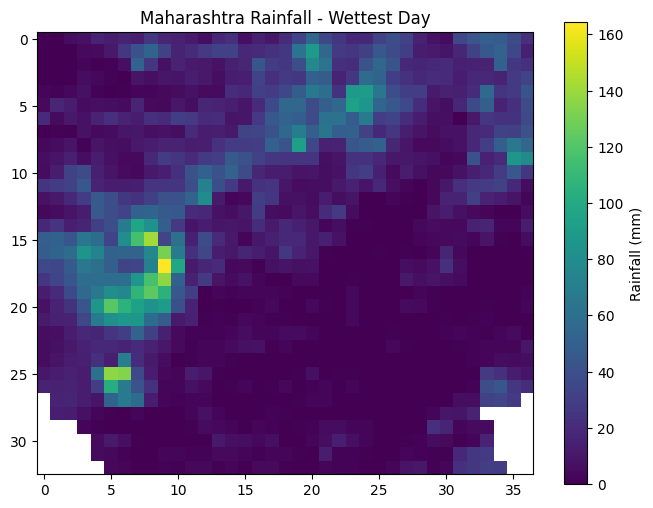

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(maha_rain)

plt.colorbar(
    label="Rainfall (mm)"
)

plt.title(
    "Maharashtra Rainfall - Wettest Day"
)

plt.show()